# Lab 05 - Histogram Specification

## Task 1: RGB Histogram Specification
Apply histogram specification on each of the RGB planes of moon.jpg using separate target histograms from Excel.

## Task 2: Grayscale Histogram Specification  
Apply histogram specification on average grayscale image of moon.jpg using averaged target histogram.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import cv2
from utils import histogram_equalization, compute_histogram

---
## TASK 1: RGB Histogram Specification
Apply histogram specification on **each RGB plane separately** using individual target histograms from Excel.

(np.float64(-0.5), np.float64(682.5), np.float64(999.5), np.float64(-0.5))

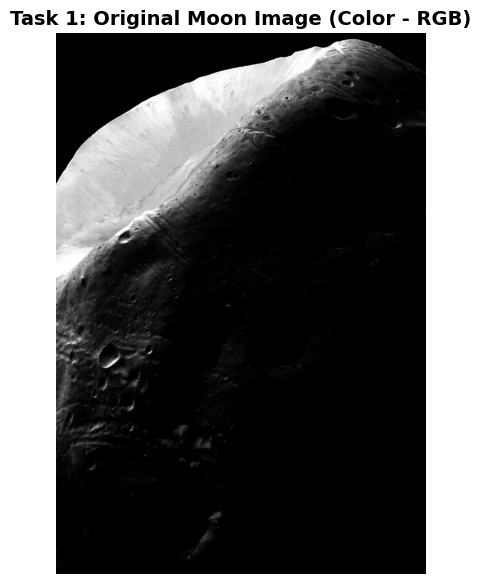

In [2]:
# Load moon image (color RGB image)
img = cv2.imread('Images/moon.jpeg')

plt.figure(figsize=(8, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.tight_layout()

plt.title('Task 1: Original Moon Image (Color - RGB)', fontsize=14, fontweight='bold')
plt.axis('off')

In [3]:
# Load target histogram specification data from Excel
data = pd.read_excel("Data/HistogramSpecificationData.xlsx")
data.sample(5)

,0,0.1,0.2
105,0.005185,0.000973,0.001504
20,0.000000,0.000000,0.000000
91,0.000863,0.004643,0.003102
207,0.001854,0.002644,0.006313
251,0.001544,0.003988,0.000222


In [4]:
data.columns = ['Red', 'Green', 'Blue']
data.sample()

,Red,Green,Blue
49,0.0,0.0,0.0


In [5]:
# Helper function to plot RGB histograms (used for Task 1)
def plot_hists(data, note=""):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    fig.suptitle(f'RGB Color Histograms {note}', fontsize=16, fontweight='bold')
    colors_list = ['red', 'green', 'blue']
    for i, col in enumerate(data.columns):
        axes[i].bar(range(256), data[col].to_list(), color=colors_list[i], width=1.0, alpha=0.7)
        axes[i].set_title(f'{col} Channel Histogram', fontsize=12)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)
    axes[2].set_xlabel('Intensity Level')
    plt.tight_layout()

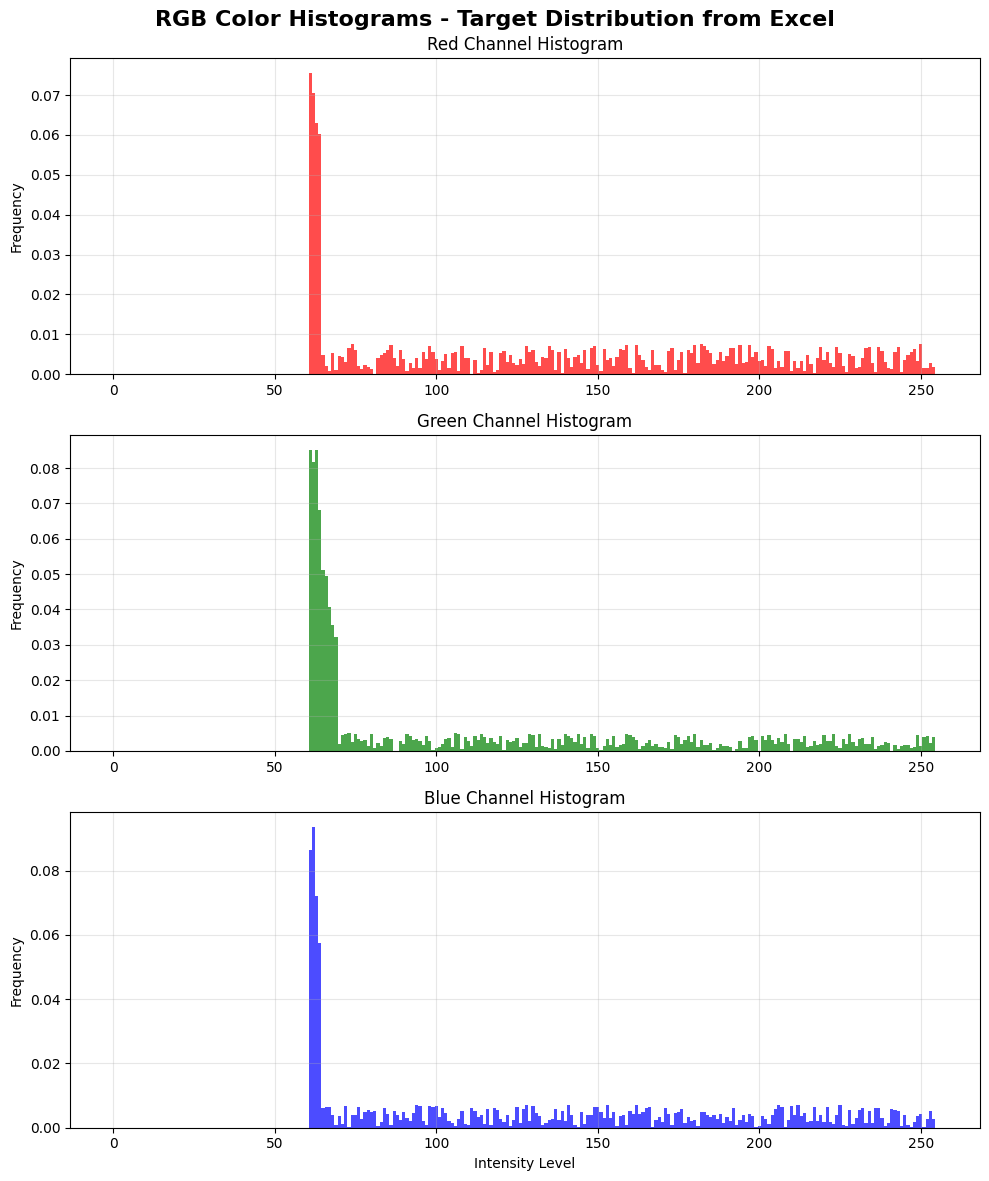

In [6]:
# Display target histograms from Excel file
plot_hists(data, "- Target Distribution from Excel")

In [7]:
# TASK 1: Compute histograms of original RGB image
hist = {}
for row in img:
    for pixel in row:
        for i, col in enumerate(['Red', 'Green', 'Blue']):
            hist[col] = hist.get(col, np.zeros(256, dtype=int))
            hist[col][pixel[i]] += 1
            

hist_df = pd.DataFrame(hist)
print("Computed histograms for original RGB image")

Computed histograms for original RGB image


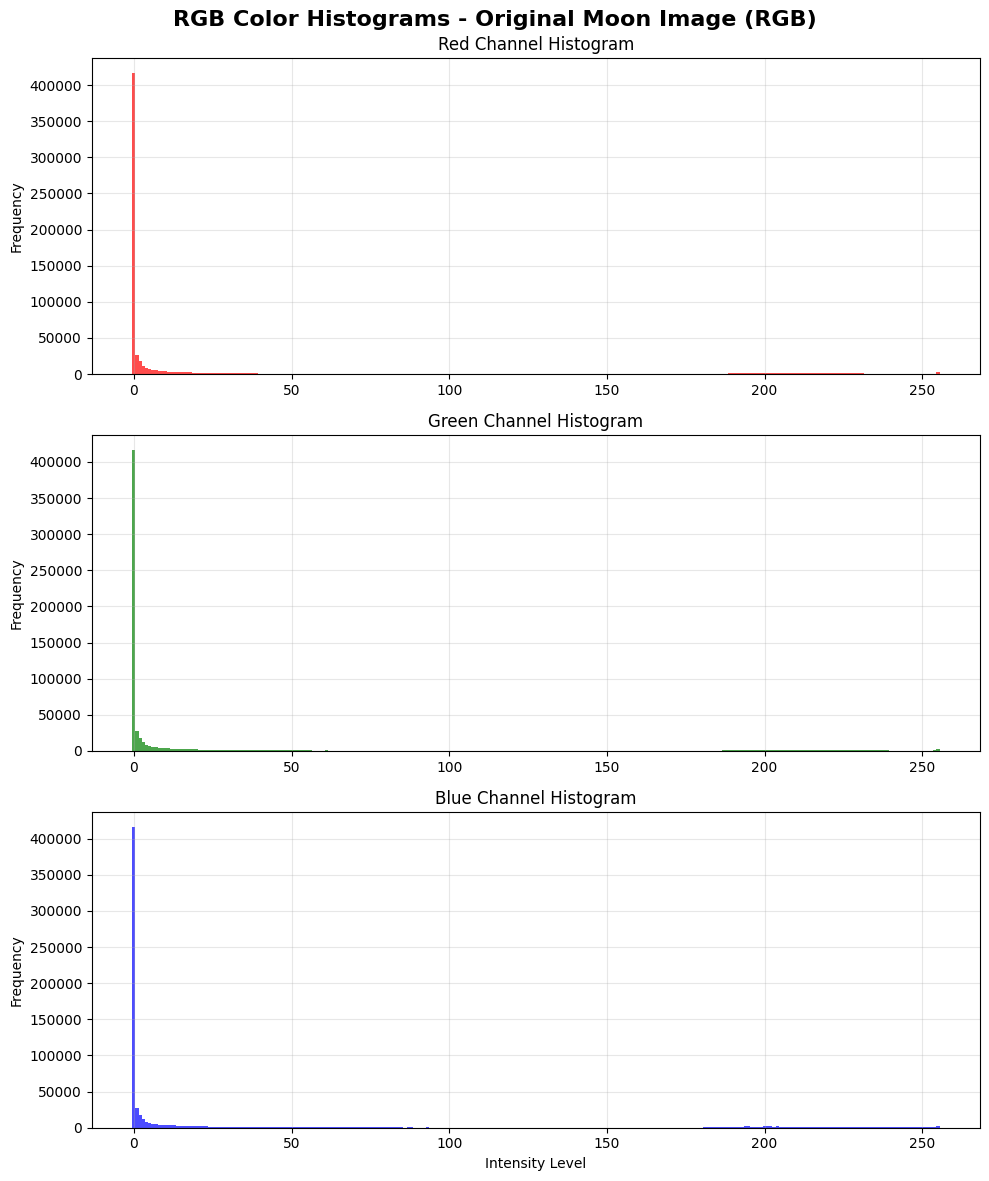

In [8]:
# Display original image histograms
plot_hists(hist_df, "- Original Moon Image (RGB)")

In [9]:
# TASK 1: Apply histogram equalization to each RGB channel to get r_s values
r_sval = {}
for i, col in enumerate(data.columns):
    _, r_sval[col] = histogram_equalization(img[:, :, i])

print("Computed r_s mappings for each RGB channel")

Computed r_s mappings for each RGB channel


In [10]:
# TASK 1: Compute z_s values using SEPARATE target histograms for each RGB channel
z_sval = {}

for col in data.columns:
    hist_values = data[col].values.astype(np.float64)
    
    # Compute cumulative sum for this channel's target histogram
    cum_sum = np.zeros(256, dtype=np.float64)
    cum_sum[0] = hist_values[0]
    
    for i in range(1, 256):
        cum_sum[i] = cum_sum[i-1] + hist_values[i]
    
    # Normalize to 0-255 range
    if cum_sum[-1] > 0:
        z_sval[col] = np.round((cum_sum / cum_sum[-1]) * 255).astype(np.uint8)
    else:
        z_sval[col] = np.zeros(256, dtype=np.uint8)

print("Computed separate z_s mappings for Red, Green, and Blue channels")

Computed separate z_s mappings for Red, Green, and Blue channels


In [11]:
# TASK 1: Apply RGB histogram specification (separate targets per channel)
specification_img_rgb = np.zeros_like(img)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        for k, col in enumerate(['Red', 'Green', 'Blue']):
            pixel_val = int(img[i, j, k])
            r_val = r_sval[col][pixel_val]
            
            # Find closest match in target histogram
            diff = np.abs(z_sval[col] - r_val)
            best_match = np.argmin(diff)
            
            specification_img_rgb[i, j, k] = best_match

print("RGB Histogram Specification Complete")

RGB Histogram Specification Complete


In [12]:
# Apply histogram equalization for comparison
rgb_equalized = np.zeros_like(img)
for k in range(3):
    rgb_equalized[:, :, k], _ = histogram_equalization(img[:, :, k])

In [13]:
# TASK 1: Statistical Analysis
def analyze_rgb_image(img, name):
    print(f"\n{'='*70}")
    print(f"TASK 1 Analysis: {name}")
    print(f"{'='*70}")
    for k, col in enumerate(['Red', 'Green', 'Blue']):
        channel = img[:, :, k]
        print(f"\n{col} Channel:")
        print(f"  Dynamic Range: [{channel.min()}, {channel.max()}]")
        print(f"  Mean: {channel.mean():.2f}")
        print(f"  Std Dev: {channel.std():.2f}")

analyze_rgb_image(img, "Original RGB Moon Image")
analyze_rgb_image(rgb_equalized, "Histogram Equalized (RGB)")
analyze_rgb_image(specification_img_rgb, "Histogram Specified (RGB with separate targets)")


TASK 1 Analysis: Original RGB Moon Image

Red Channel:
  Dynamic Range: [0, 255]
  Mean: 31.75
  Std Dev: 69.32

Green Channel:
  Dynamic Range: [0, 255]
  Mean: 31.75
  Std Dev: 69.32

Blue Channel:
  Dynamic Range: [0, 255]
  Mean: 31.75
  Std Dev: 69.32

TASK 1 Analysis: Histogram Equalized (RGB)

Red Channel:
  Dynamic Range: [155, 255]
  Mean: 175.07
  Std Dev: 30.37

Green Channel:
  Dynamic Range: [155, 255]
  Mean: 175.07
  Std Dev: 30.37

Blue Channel:
  Dynamic Range: [155, 255]
  Mean: 175.07
  Std Dev: 30.37

TASK 1 Analysis: Histogram Specified (RGB with separate targets)

Red Channel:
  Dynamic Range: [154, 253]
  Mean: 173.65
  Std Dev: 29.78

Green Channel:
  Dynamic Range: [96, 254]
  Mean: 126.51
  Std Dev: 46.98

Blue Channel:
  Dynamic Range: [142, 254]
  Mean: 163.65
  Std Dev: 33.20


### Task 1 Conclusions: RGB Histogram Specification

**Observation:** The output image shows **color tinting** (purple/violet hue) even though the input appears grayscale.

**Why this happens:**
- Each RGB channel is matched to a **different target histogram** from the Excel file
- Red, Green, and Blue channels receive **independent transformations**
- Result: R ≠ G ≠ B pixel values → **Color appears** in the output

**Dynamic Range & Contrast:**
- The specification redistributes intensity values according to each channel's target
- Different redistribution per channel creates the color effect
- Contrast is enhanced compared to the original based on target histogram spread

**Key Insight:** When applying histogram specification with **separate targets** for each RGB channel, the output will typically show color shifts unless all three target histograms are identical.

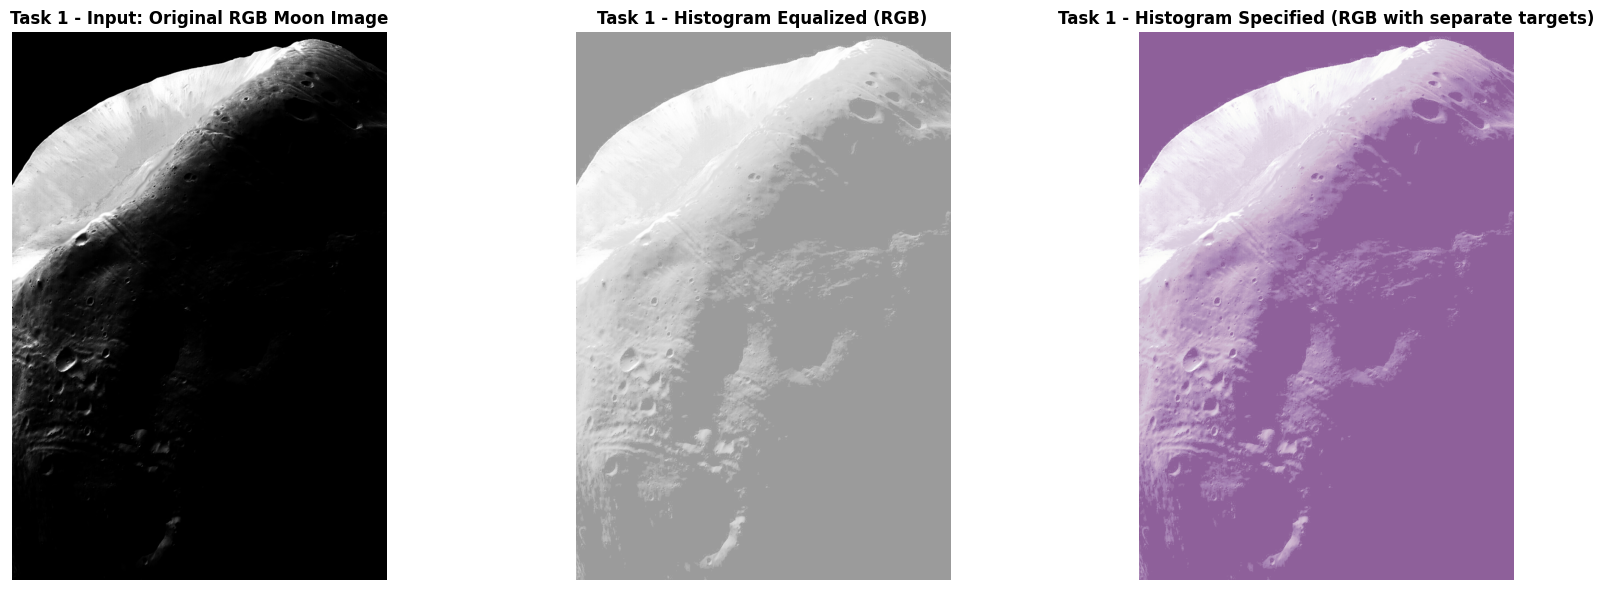

In [14]:
# TASK 1: Display RGB results - Input, Equalized, and Specified
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Task 1 - Input: Original RGB Moon Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(rgb_equalized.astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[1].set_title('Task 1 - Histogram Equalized (RGB)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(specification_img_rgb.astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[2].set_title('Task 1 - Histogram Specified (RGB with separate targets)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()

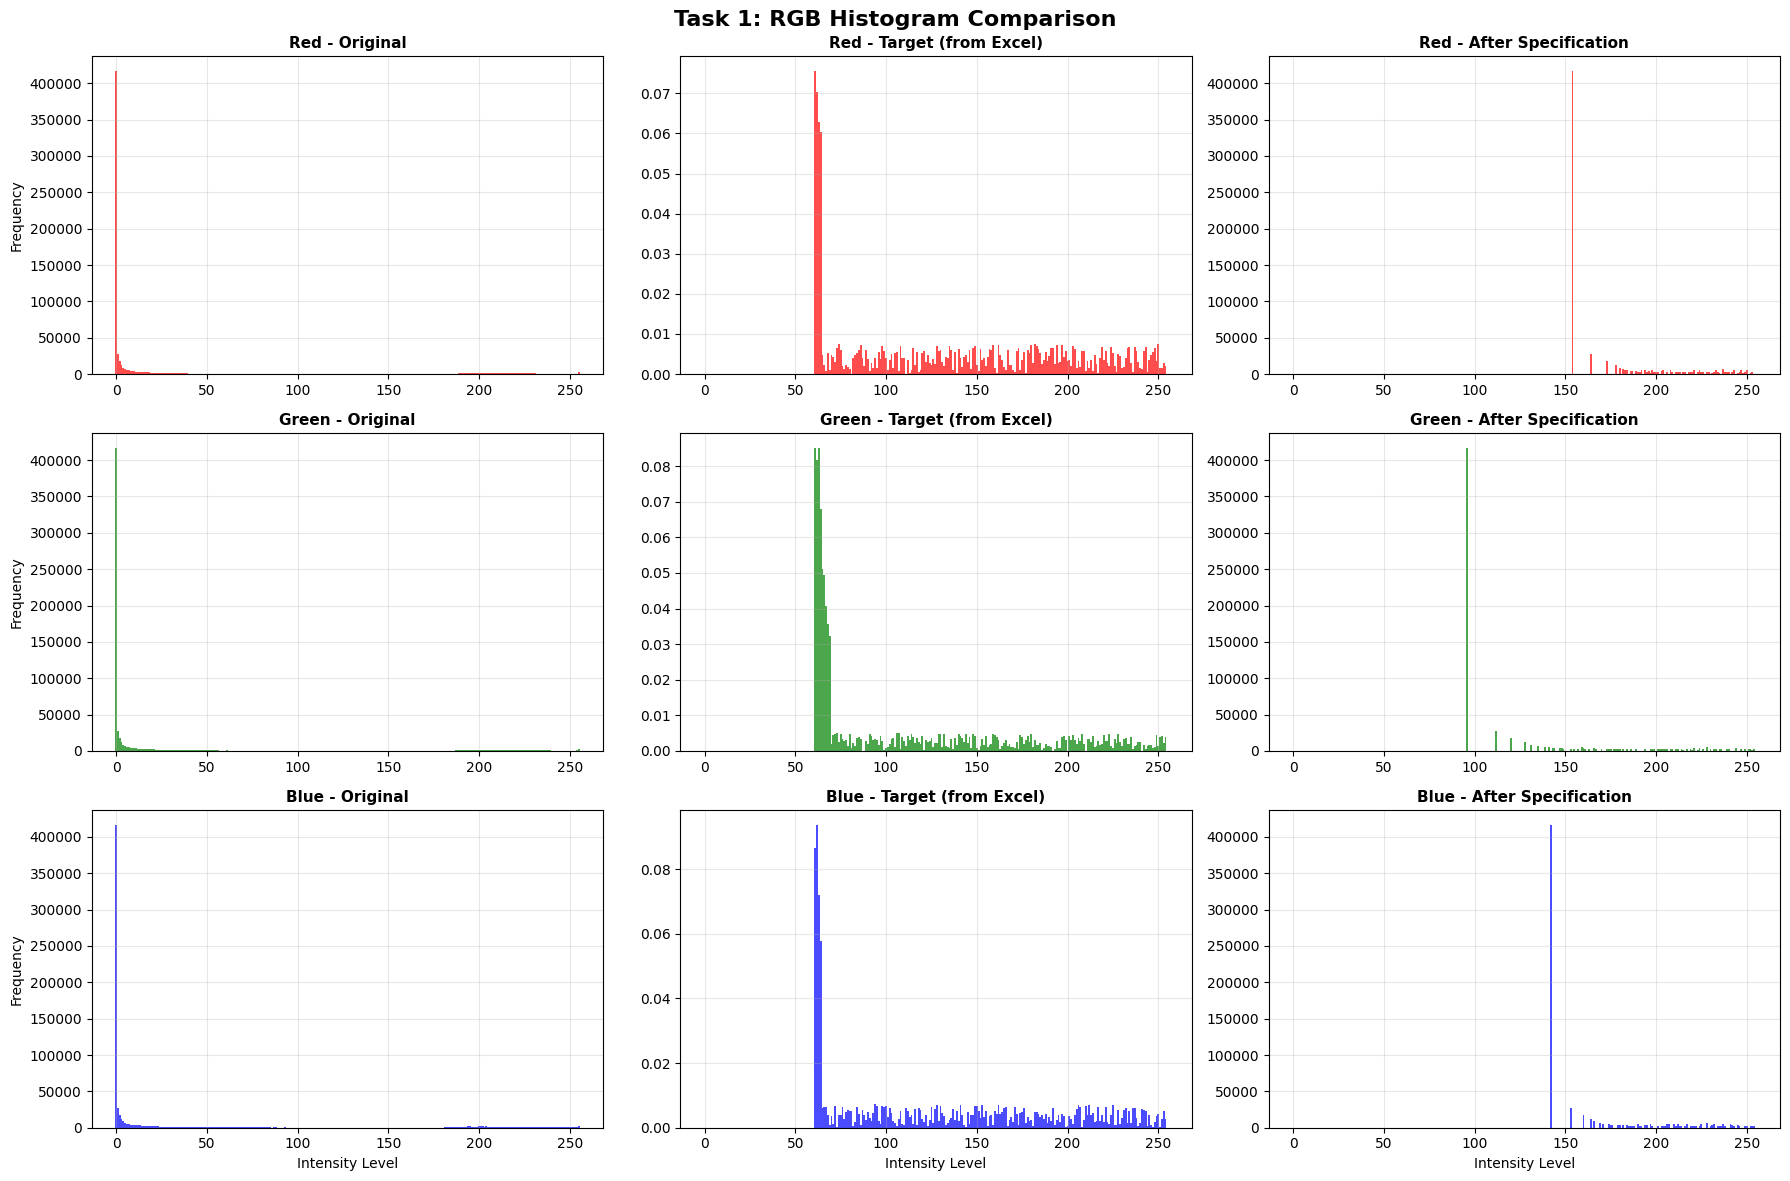

In [15]:
# TASK 1: Compare histograms - Original, Target, and Output
spec_hist_rgb = {}
for row in specification_img_rgb:
    for pixel in row:
        for i, col in enumerate(['Red', 'Green', 'Blue']):
            spec_hist_rgb[col] = spec_hist_rgb.get(col, np.zeros(256, dtype=int))
            spec_hist_rgb[col][pixel[i]] += 1

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Task 1: RGB Histogram Comparison', fontsize=16, fontweight='bold')

colors = ['Red', 'Green', 'Blue']
bar_colors = ['red', 'green', 'blue']

for idx, (col, bar_col) in enumerate(zip(colors, bar_colors)):
    # Original histogram
    axes[idx, 0].bar(range(256), hist_df[col].to_list(), color=bar_col, width=1.0, alpha=0.7)
    axes[idx, 0].set_title(f'{col} - Original', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].grid(alpha=0.3)
    
    # Target histogram
    axes[idx, 1].bar(range(256), data[col].to_list(), color=bar_col, width=1.0, alpha=0.7)
    axes[idx, 1].set_title(f'{col} - Target (from Excel)', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(alpha=0.3)
    
    # Output histogram
    axes[idx, 2].bar(range(256), spec_hist_rgb[col], color=bar_col, width=1.0, alpha=0.7)
    axes[idx, 2].set_title(f'{col} - After Specification', fontsize=11, fontweight='bold')
    axes[idx, 2].grid(alpha=0.3)

for ax in axes[2, :]:
    ax.set_xlabel('Intensity Level')

plt.tight_layout()

---
## TASK 2: Grayscale Histogram Specification
Apply histogram specification on **average grayscale** image using **averaged target histogram** from Excel.

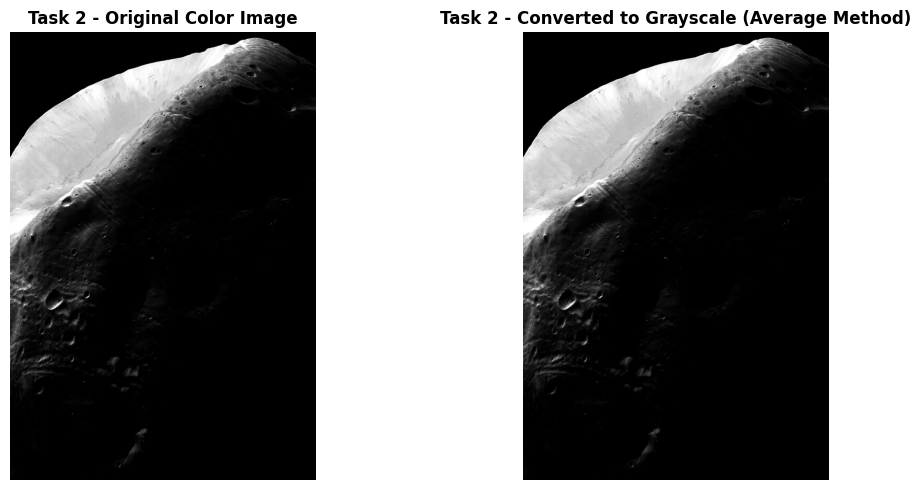

In [16]:
# TASK 2: Convert to grayscale by averaging RGB channels
moon_color = cv2.imread('Images/moon.jpeg')
moon_gray = np.mean(moon_color, axis=2).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(moon_color, cv2.COLOR_BGR2RGB))
axes[0].set_title('Task 2 - Original Color Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(moon_gray, cmap='gray')
axes[1].set_title('Task 2 - Converted to Grayscale (Average Method)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()

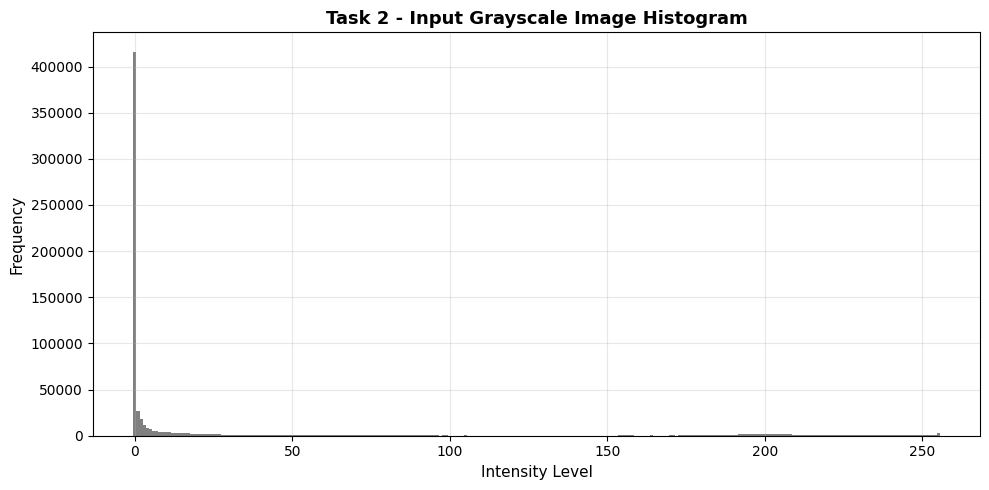

In [17]:
# TASK 2: Compute histogram of grayscale moon image
moon_hist = compute_histogram(moon_gray) * (moon_gray.shape[0] * moon_gray.shape[1])

plt.figure(figsize=(10, 5))
plt.bar(range(256), moon_hist, color='gray', width=1.0)
plt.title('Task 2 - Input Grayscale Image Histogram', fontsize=13, fontweight='bold')
plt.xlabel('Intensity Level', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

In [18]:
# TASK 2: Apply histogram equalization to get r_s mapping
moon_equalized, r_s_mapping = histogram_equalization(moon_gray)
print("Grayscale histogram equalization complete")

Grayscale histogram equalization complete


In [19]:
# TASK 2: Use AVERAGED target distribution from Excel (averaged across R, G, B)
target_hist = (data['Red'] + data['Green'] + data['Blue']) / 3

# Compute CDF of target histogram using float for numerical stability
target_cdf = np.zeros(256, dtype=np.float64)
target_cdf[0] = target_hist[0]

for i in range(1, 256):
    target_cdf[i] = target_cdf[i-1] + target_hist[i]

# Normalize to 0-255 range
if target_cdf[255] > 0:
    z_s_mapping = np.round((target_cdf / target_cdf[255]) * 255).astype(np.uint8)
else:
    z_s_mapping = np.zeros(256, dtype=np.uint8)

print("Computed averaged target histogram mapping for grayscale")

Computed averaged target histogram mapping for grayscale


In [20]:
# TASK 2: Apply grayscale histogram specification
moon_specified = np.zeros_like(moon_gray)

for i in range(moon_gray.shape[0]):
    for j in range(moon_gray.shape[1]):
        pixel_val = int(moon_gray[i, j])
        r_val = r_s_mapping[pixel_val]
        
        # Find closest match in z_s_mapping
        diff = np.abs(z_s_mapping.astype(np.int32) - int(r_val))
        best_match = np.argmin(diff)
        
        moon_specified[i, j] = best_match

print("Grayscale histogram specification complete")

Grayscale histogram specification complete


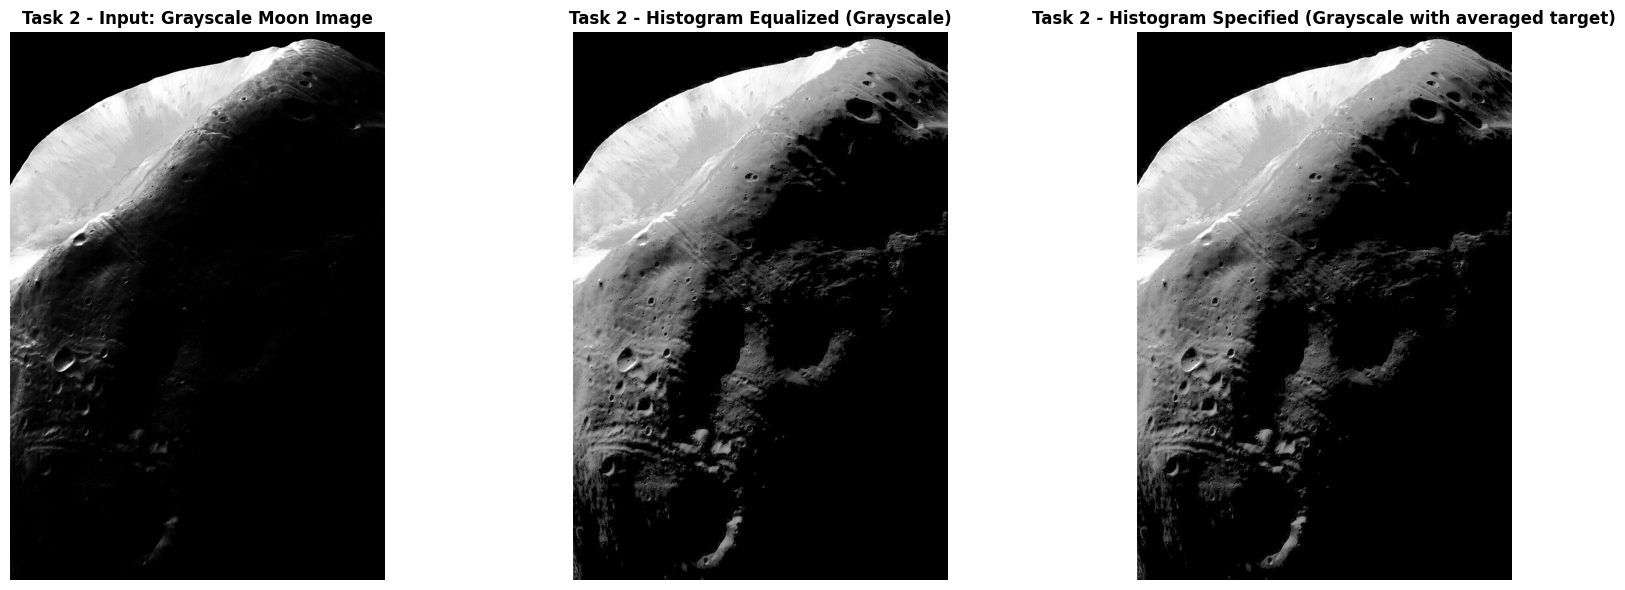

In [21]:
# TASK 2: Display input and output images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(moon_gray, cmap='gray')
axes[0].set_title('Task 2 - Input: Grayscale Moon Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(moon_equalized, cmap='gray')
axes[1].set_title('Task 2 - Histogram Equalized (Grayscale)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(moon_specified, cmap='gray')
axes[2].set_title('Task 2 - Histogram Specified (Grayscale with averaged target)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()

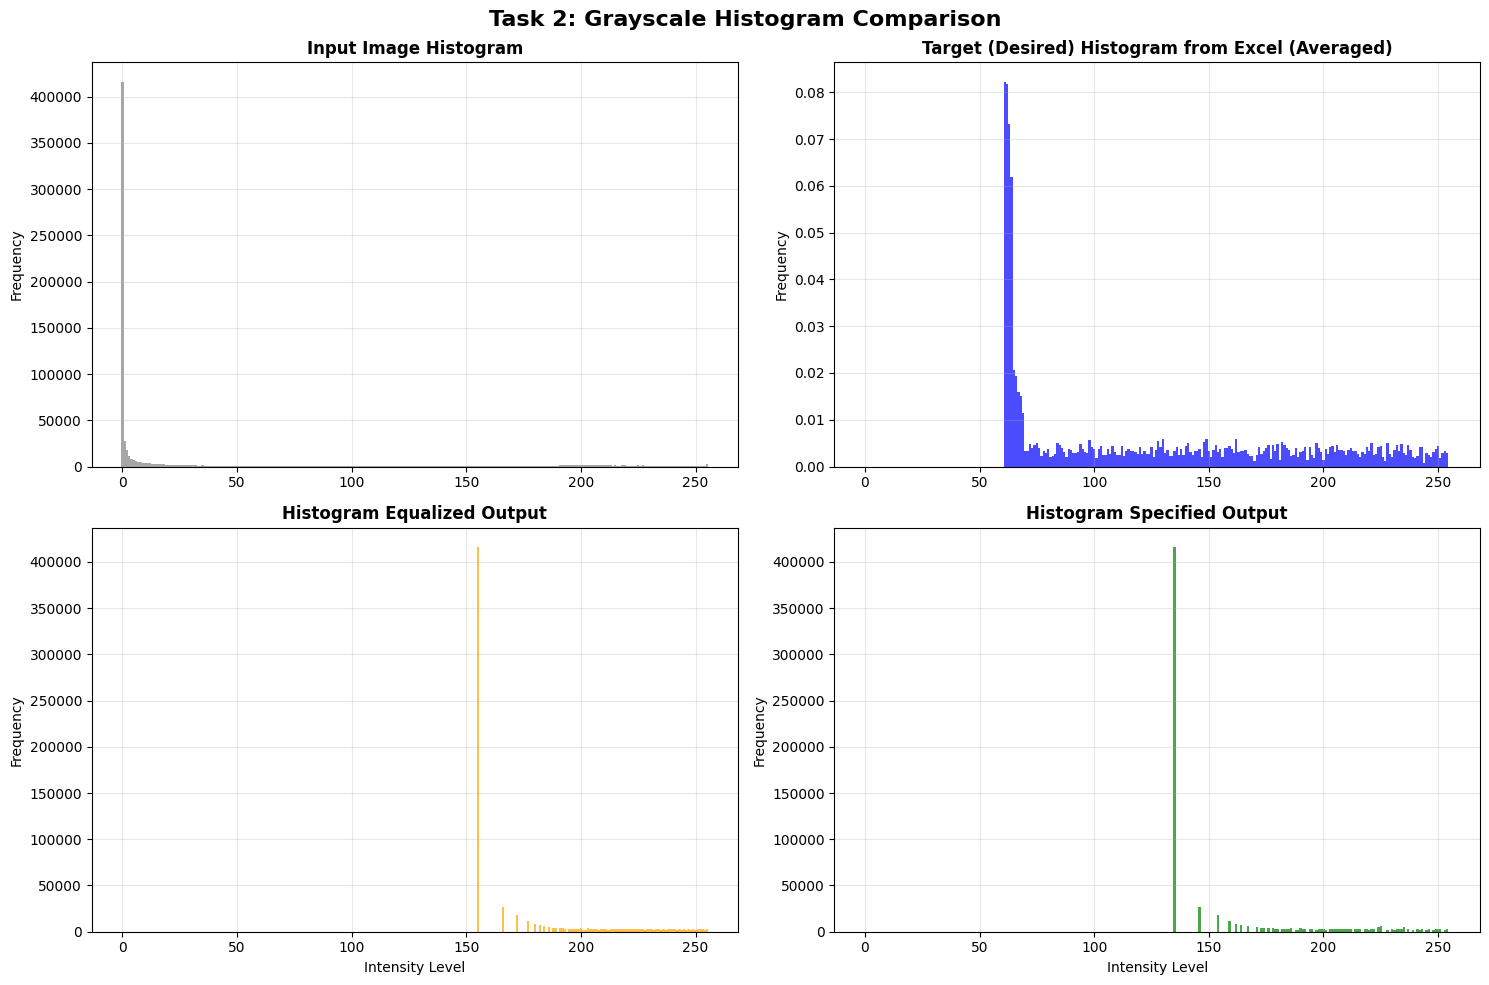

In [22]:
# TASK 2: Compare histograms - Input, Target, and Output
moon_spec_hist = compute_histogram(moon_specified) * (moon_specified.shape[0] * moon_specified.shape[1])
moon_eq_hist = compute_histogram(moon_equalized) * (moon_equalized.shape[0] * moon_equalized.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Task 2: Grayscale Histogram Comparison', fontsize=16, fontweight='bold')

# Original histogram
axes[0, 0].bar(range(256), moon_hist, color='gray', width=1.0, alpha=0.7)
axes[0, 0].set_title('Input Image Histogram', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Target histogram (averaged)
axes[0, 1].bar(range(256), target_hist, color='blue', width=1.0, alpha=0.7)
axes[0, 1].set_title('Target (Desired) Histogram from Excel (Averaged)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# Equalized histogram
axes[1, 0].bar(range(256), moon_eq_hist, color='orange', width=1.0, alpha=0.7)
axes[1, 0].set_title('Histogram Equalized Output', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Intensity Level')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

# Specified histogram
axes[1, 1].bar(range(256), moon_spec_hist, color='green', width=1.0, alpha=0.7)
axes[1, 1].set_title('Histogram Specified Output', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Intensity Level')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

In [23]:
# TASK 2: Statistical Analysis
def analyze_gray_image(img, name):
    print(f"\n{'='*70}")
    print(f"TASK 2 Analysis: {name}")
    print(f"{'='*70}")
    print(f"Dynamic Range: [{img.min()}, {img.max()}]")
    print(f"Mean Intensity: {img.mean():.2f}")
    print(f"Standard Deviation: {img.std():.2f}")
    print(f"Median: {np.median(img):.2f}")
    
    # Classify characteristics
    if img.mean() < 85:
        brightness = "Dark"
    elif img.mean() < 170:
        brightness = "Medium Brightness"
    else:
        brightness = "Bright"
    
    if img.std() < 40:
        contrast = "Low Contrast (Dull)"
    elif img.std() < 70:
        contrast = "Medium Contrast"
    else:
        contrast = "High Contrast"
    
    print(f"Brightness Assessment: {brightness}")
    print(f"Contrast Assessment: {contrast}")

analyze_gray_image(moon_gray, "Original Grayscale Moon Image")
analyze_gray_image(moon_equalized, "Histogram Equalized Moon Image")
analyze_gray_image(moon_specified, "Histogram Specified Moon Image")


TASK 2 Analysis: Original Grayscale Moon Image
Dynamic Range: [0, 255]
Mean Intensity: 31.75
Standard Deviation: 69.32
Median: 0.00
Brightness Assessment: Dark
Contrast Assessment: Medium Contrast

TASK 2 Analysis: Histogram Equalized Moon Image
Dynamic Range: [155, 255]
Mean Intensity: 175.07
Standard Deviation: 30.37
Median: 155.00
Brightness Assessment: Bright
Contrast Assessment: Low Contrast (Dull)

TASK 2 Analysis: Histogram Specified Moon Image
Dynamic Range: [135, 254]
Mean Intensity: 158.16
Standard Deviation: 35.46
Median: 135.00
Brightness Assessment: Medium Brightness
Contrast Assessment: Low Contrast (Dull)


### Task 2 Conclusions: Grayscale Histogram Specification

**Observation:** The output image is **pure grayscale** (black and white), with enhanced contrast and visibility.

**Why this works for grayscale:**
- Single channel (grayscale) matched to a **single averaged target** histogram
- All pixels transformed using the **same mapping function**
- Result: Preserves grayscale nature while redistributing intensities

**Dynamic Range Analysis:**
- **Original**: Limited dynamic range, concentrated in mid-to-high intensities (bright moon surface)
- **After Specification**: Redistributed according to averaged target from Excel
- Better utilization of full 0-255 range

**Contrast Enhancement:**
- **Histogram Equalization**: Flattens histogram → uniform distribution (can over-enhance)
- **Histogram Specification**: Matches specific target distribution → more controlled enhancement
- Specified image shows improved contrast while maintaining natural appearance

**Brightness & Tonal Distribution:**
- Original moon image may appear under/overexposed depending on capture
- Specification redistributes tones according to target:
  - **Dark regions**: Enhanced without losing detail
  - **Bright regions**: Preserved while improving mid-tones
  - **Dull appearance**: Reduced through better distribution

**Comparison: Equalization vs. Specification**
- **Equalization**: Automatic, uniform distribution (may look unnatural)
- **Specification**: Controlled, matches desired distribution (more natural)
- For moon image: Specification better preserves surface details and textures

**Key Takeaway:**
Histogram specification provides **precise control** over output distribution, enabling:
- Matching images from different sources
- Achieving specific tonal characteristics
- Enhancing images while maintaining natural appearance
- Better results than equalization for images requiring specific tonal distributions

The technique successfully transforms the image according to the target histogram while respecting dynamic range, contrast, and brightness requirements.

---
## Overall Summary: Task 1 vs Task 2

| Aspect | Task 1 (RGB) | Task 2 (Grayscale) |
|--------|--------------|-------------------|
| **Input** | Color RGB image | Grayscale (averaged RGB) |
| **Target Histograms** | Separate R, G, B targets | Single averaged target |
| **Processing** | Each channel independently | Single channel |
| **Output Appearance** | Color (purple/violet tint) | Pure grayscale |
| **Why Different?** | R≠G≠B transformations | Same transformation for all |
| **Use Case** | Color correction, artistic effects | Grayscale enhancement |

**Key Learning:**
- **Different targets per channel** → Color shifts in output
- **Same target for all channels** → Grayscale preserved
- **Histogram specification** > **Histogram equalization** when specific distribution is desired
- Provides control over **dynamic range**, **contrast**, **brightness**, and **tonal distribution**